In [1]:
what_were_covering = {
    1: "data (prepare and load)",
    2: "build model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating the model",
    5: "saving and loading the model",
    6: "putting it all together (end-to-end example)"
}
what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating the model',
 5: 'saving and loading the model',
 6: 'putting it all together (end-to-end example)'}

In [115]:
import torch
from torch import nn ## nn contains all of the modules, classes, functions etc. needed to build neural networks
import matplotlib.pyplot as plt
import numpy as np

torch.__version__

'2.7.1+cpu'

In [3]:
weight = 0.3
bias = 0.7

#create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1) # unsqueeze adds a dimension to the tensor
y = weight * X + bias

In [4]:
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.7000],
         [0.7060],
         [0.7120],
         [0.7180],
         [0.7240],
         [0.7300],
         [0.7360],
         [0.7420],
         [0.7480],
         [0.7540]]))

In [5]:
X.shape

torch.Size([50, 1])

In [6]:
train_split = int(0.8 * len(X))
train_split

40

In [7]:
X_train, y_train = X[:train_split], y[:train_split]

In [8]:
X_test, y_test = X[train_split:], y[train_split:]

In [9]:
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

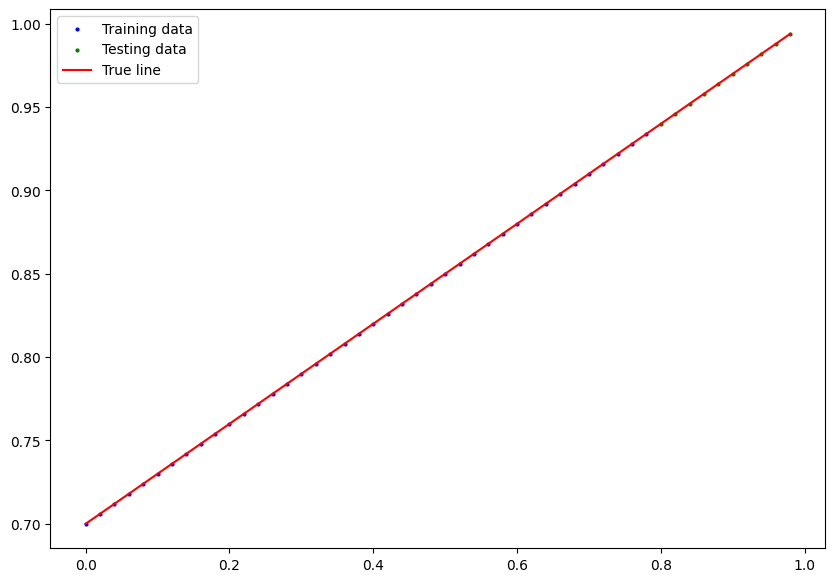

In [10]:
plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")
plt.scatter(X_test, y_test, c="g", s=4, label="Testing data")
plt.plot(X, weight * X + bias, c="r", label="True line")
plt.legend()

In [11]:
names = ['Ala', 'Bartek']
scores = [5, 4]

# Pythonic
for name, score in zip(names, scores):
    print(f"{name} has score {score}")


Ala has score 5
Bartek has score 4


In [12]:
lista = [n for n in range(10) if n % 2 == 0]
lista

[0, 2, 4, 6, 8]

In [13]:
words = ['cat', 'dog', 'cat', 'bird']
from collections import Counter
counts = Counter(words)
counts

Counter({'cat': 2, 'dog': 1, 'bird': 1})

In [14]:
words.count('cat')

2

In [15]:
files = ['a.txt', 'b.csv', 'notes.txt', 'README.md']
txt_files = [f for f in files if f.endswith('.txt')]
txt_files

['a.txt', 'notes.txt']

In [16]:
files = ['a.txt', 'b.csv', 'notes.txt', 'README.md']
title = ['1', '2', '3', '4','5']

In [17]:
for file, titles in zip(files, title):
    print(f"File: {file}, Title: {titles}")

File: a.txt, Title: 1
File: b.csv, Title: 2
File: notes.txt, Title: 3
File: README.md, Title: 4


What model does:
* start with random values (weight and bias)
* look at traning data and adjust the random values to better represent (or get closer to) the ideal values (the weights and bias vaqlues we used to create the data)

How does it do so?
Through two main algorithms
1. Gredient descent https://www.youtube.com/watch?v=IHZwWFHWa-w
2. Backpropagation https://www.youtube.com/watch?v=Ilg3gGewQ5U

In [18]:
from torch import nn

class LinearRegressionModel(nn.Module): 
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(
            torch.randn(1,
                        requires_grad=True,
                        dtype=torch.float)
        )
        self.bias = nn.Parameter(
            torch.randn(1,
                        requires_grad=True,
                        dtype=torch.float)
        )

        #forward method to define the computation in the model

    def forward(self, x:torch.Tensor) -> torch.Tensor: # x<- is the input data
        return self.weights * x + self.bias

### PyTorch model building essentials

* torch.nn - contains all of the building for computional graphs (another word for neural networks)
* torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us
* torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward()
* torch.optim - this where the optimizers in pytorch live, they will help with gradient descent
* def forward() - All nn.Module subclasses require to overwrite forward(), this method defines what happens in the forward computation

### Checking the contents of our PyTorch model

Now we've created a model, let's see what's inside... 

So we can check our model parameters or whats inside our model using .parameters()

In [126]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [20]:
torch.manual_seed(42)
torch.randn(1), torch.randn(1)

(tensor([0.3367]), tensor([0.1288]))

In [21]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [22]:
weight, bias

(0.3, 0.7)

### Making prediction using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts 'y_test' based on 'X_test'.

When we pass data through our model, it's godzin to run it through the `forward()` method.

In [23]:
y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [24]:
# Make predictions with model - torch.inference_mode() moze sprawaiac ze predykcje beda szybsze - do doczytania ocb

with torch.inference_mode():
    y_preds = model_0(X_test)

# You can also do somethhing similar torch.no_grad(), however torch.inference_mode() is preffered
# with torch.no_grad():
#     y_preds = model_0(X_test)


y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

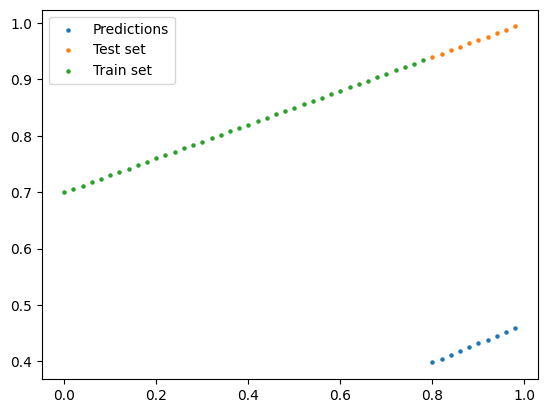

In [25]:
plt.scatter(x = X_test, y = y_preds, s = 5, label = 'Predictions')
plt.scatter(x = X_test, y = y_test, s = 5, label = 'Test set')
plt.scatter(x = X_train, y = y_train, s = 5, label = 'Train set')
plt.legend()

In [26]:
(((y_test - y_preds)*2).sum())/len(y_test) # MSE

tensor(1.0771)

In [27]:
(((y_test - y_preds)*2).sum()/len(y_test)).sqrt() # RMSE

tensor(1.0378)

In [28]:
((y_test - y_preds).abs().sum())/len(y_test) # MAE

tensor(0.5385)

## 3. Train model

The whole idea of training is for a model to move from some *unknown* parameters (these may be random) to some *known* parameters,

Or in other words from a poor representation of the data to a better representation of a data.

One way to measure how poor or how worng your models predictions are is to use a loss function.

* Note: Loss function may also be called cost funtion or criterion in defferent areas. For our case, we're going to refer to it as a loss function

Things we need to train:

* **Loss function:** A function to measure how wrong your model's predctioions are to the ideal outputs. Lower is better.

* **Optimizer:** Takes into account the loss of a model and adjust the model's parameters (e.g. weight and bias in our case) to impore the loss function

And a specifically for pytorch, we need:
* a training loop
* a testing loop

In [29]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [30]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [127]:
# Setup a loss function 

loss_fn = nn.L1Loss()

# Setup an optimizer #stochastic gradient descent

optimizer = torch.optim.SGD(params = model_0.parameters()
                            , lr = 0.005 # learning rate - opossibly the most important hyperparameter you can set
                            ) 

In [32]:
loss_fn, optimizer

(L1Loss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.01
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

### Building a training loo (and a testing loop) in PyTorch

A couple of things we need in a training loop:
0. Loop through the data
1. Forward pass (this involves data moving through our model's `forward()` functions) to make predictiosn on data - also called forward propagations
2. calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the lose (**backpropagation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)

In [33]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [34]:
with torch.inference_mode():
    print(list(model_0.parameters()))

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


In [128]:
epochs = 1000 # hyperparameter, because weve set it by ourselves


# track different values
epoch_count = []
loss_values = []
test_loss_valies = []


# step 0
for epoch in range(epochs):
    # set the model to training mode
    model_0.train() # train mode in PyTorch sets all parameters that require gradients to require gradients
 
    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate a loss
    loss = loss_fn(y_pred, y_train)

    # print(f'Loss: {loss}')

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropagation on the loss with respect to the parameters of the model
    loss.backward()

    # 5. Step the optimizer (perform gradient descent)
    optimizer.step() # by default how the optimizer changes will accumulate through the loop 
                    # so we have to zero them above in step 3 in the next iteration of the loop

    ### testing
    model_0.eval() #turns off greadient tracking # turns off different settings in the model not needed for evaluation/testing
    
    with torch.inference_mode():
        # 1. Do to forward pass
        test_pred = model_0(X_test)

        # 2. Calcualte the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_valies.append(test_loss)
        print(f'Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}')

    # print(model_0.state_dict())


Epoch: 0 | Loss: 0.556881308555603 | Test loss: 0.5318006873130798
Epoch: 10 | Loss: 0.49927639961242676 | Test loss: 0.4644457697868347
Epoch: 20 | Loss: 0.4416714608669281 | Test loss: 0.3970908224582672
Epoch: 30 | Loss: 0.38406652212142944 | Test loss: 0.3297359347343445
Epoch: 40 | Loss: 0.3264616131782532 | Test loss: 0.26238101720809937
Epoch: 50 | Loss: 0.26885664463043213 | Test loss: 0.19502608478069305
Epoch: 60 | Loss: 0.21125170588493347 | Test loss: 0.12767118215560913
Epoch: 70 | Loss: 0.1536467969417572 | Test loss: 0.06031625345349312
Epoch: 80 | Loss: 0.09604181349277496 | Test loss: 0.010990339331328869
Epoch: 90 | Loss: 0.055303312838077545 | Test loss: 0.05875270441174507
Epoch: 100 | Loss: 0.04548146575689316 | Test loss: 0.0790121778845787
Epoch: 110 | Loss: 0.041958488523960114 | Test loss: 0.08680246025323868
Epoch: 120 | Loss: 0.03981325775384903 | Test loss: 0.08821047842502594
Epoch: 130 | Loss: 0.038049180060625076 | Test loss: 0.086135134100914
Epoch: 140 

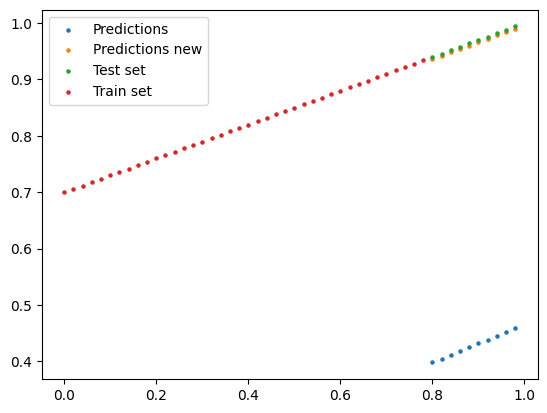

In [152]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

plt.scatter(x = X_test, y = y_preds, s = 5, label = 'Predictions')
plt.scatter(x = X_test, y = y_preds_new, s = 5, label = 'Predictions new')
plt.scatter(x = X_test, y = y_test, s = 5, label = 'Test set')
plt.scatter(x = X_train, y = y_train, s = 5, label = 'Train set')
plt.legend()

In [131]:
epoch_count, loss_values, test_loss_valies

([0,
  10,
  20,
  30,
  40,
  50,
  60,
  70,
  80,
  90,
  100,
  110,
  120,
  130,
  140,
  150,
  160,
  170,
  180,
  190,
  200,
  210,
  220,
  230,
  240,
  250,
  260,
  270,
  280,
  290,
  300,
  310,
  320,
  330,
  340,
  350,
  360,
  370,
  380,
  390,
  400,
  410,
  420,
  430,
  440,
  450,
  460,
  470,
  480,
  490,
  500,
  510,
  520,
  530,
  540,
  550,
  560,
  570,
  580,
  590,
  600,
  610,
  620,
  630,
  640,
  650,
  660,
  670,
  680,
  690,
  700,
  710,
  720,
  730,
  740,
  750,
  760,
  770,
  780,
  790,
  800,
  810,
  820,
  830,
  840,
  850,
  860,
  870,
  880,
  890,
  900,
  910,
  920,
  930,
  940,
  950,
  960,
  970,
  980,
  990],
 [tensor(0.5569, grad_fn=<MeanBackward0>),
  tensor(0.4993, grad_fn=<MeanBackward0>),
  tensor(0.4417, grad_fn=<MeanBackward0>),
  tensor(0.3841, grad_fn=<MeanBackward0>),
  tensor(0.3265, grad_fn=<MeanBackward0>),
  tensor(0.2689, grad_fn=<MeanBackward0>),
  tensor(0.2113, grad_fn=<MeanBackward0>),
  tensor(

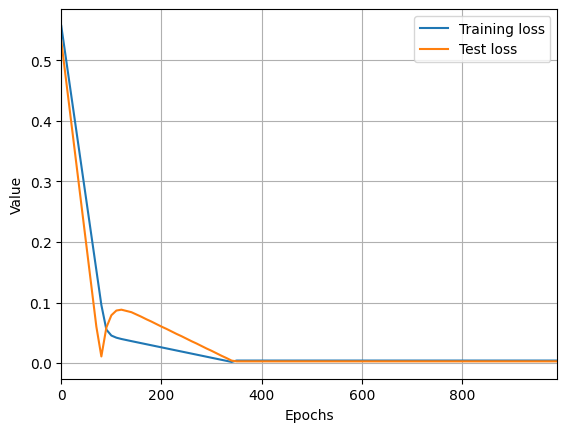

In [133]:
plt.plot(epoch_count, [t.item() for t in loss_values], label = 'Training loss')
plt.plot(epoch_count, test_loss_valies, label = 'Test loss')
# plt.xticks(torch.tensor(epoch_count)//10)
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.xlim(min(epoch_count), max((epoch_count)))
plt.legend()
plt.grid(True)

In [104]:
val = [t.item() for t in loss_values]
val

[0.556881308555603,
 0.44167131185531616,
 0.32646140456199646,
 0.21125154197216034,
 0.09604163467884064,
 0.04522073268890381,
 0.03982054069638252,
 0.03630153089761734,
 0.03286397457122803,
 0.02943551540374756,
 0.025997888296842575,
 0.02256198786199093,
 0.019133061170578003,
 0.01569424197077751,
 0.012260009534657001,
 0.008829416707158089,
 0.005390599370002747,
 0.0019580244552344084,
 0.008988434448838234,
 0.008988434448838234]

In [137]:
# 245mm
# 92mm
# 50mm

## Saving model in PyTorch

There are three main methods you should know about saving and loading models in PyTorch
1. `torch.save()` - allows you save a PyTorch project in Python's picke format
2. `torch.load()` - allows you load a saved PyTorch object
3. `torch.nn.Module.load_state_dict()` - this allows to load a model's saved state dictionary

In [139]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3006])), ('bias', tensor([0.6956]))])

In [142]:
# Saving a PyTorch model

from pathlib import Path

# 1.Create models directory
model_path = Path('models')
model_path.mkdir(parents=True, exist_ok=True)

# 2. Create model save Path
model_name = "01_pytorch_workflow_model_0.pth"
model_save_path = model_path / model_name
model_save_path

# 3. Save the model state_dict
print(f'Saving model to: {model_save_path}')
torch.save(obj=model_0.state_dict(),
           f=model_save_path)

Saving model to: models\01_pytorch_workflow_model_0.pth


Folder PATH listing
Volume serial number is 1224-6442
C:.
����models


## Loading a PyTorch model

Since we saved our model's `state_dict()` rather the entire model, we'll create a new instance of our model class and load the saved `state_dict()` into that

In [146]:
# To load in a saved state_dict() we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f=model_save_path))

<All keys matched successfully>

In [147]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.3006])), ('bias', tensor([0.6956]))])

In [148]:
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)


In [156]:
y_preds_new==loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [164]:
isinstance(y_pred, torch.Tensor)

True

## 6. Putting it all together

Lets go back through the steps above and see it in one place

In [166]:
#import PyTorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.7.1+cpu'

Create device-agnostic code.

This means if we've got access to a GPU, our code will use it (for potentially faster computing).

If No GPU is available, the code will default to using CPU

In [167]:
# Setup device agnostic code

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cpu


### 6.1 Data

In [170]:
# Create some data using the linear regression formula of y = weight * x + bias
weight = 0.6
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step=step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3120],
         [0.3240],
         [0.3360],
         [0.3480],
         [0.3600],
         [0.3720],
         [0.3840],
         [0.3960],
         [0.4080]]))

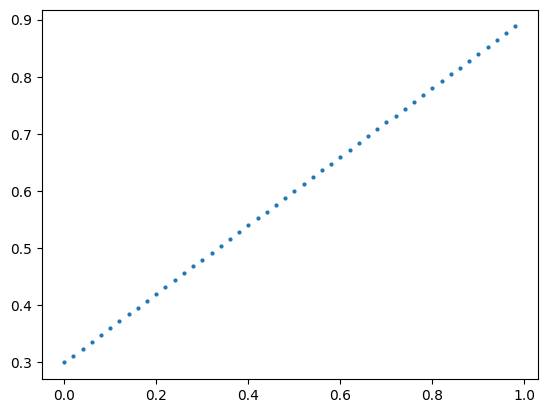

In [175]:
plt.scatter(X, y, s = 4)

In [176]:
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

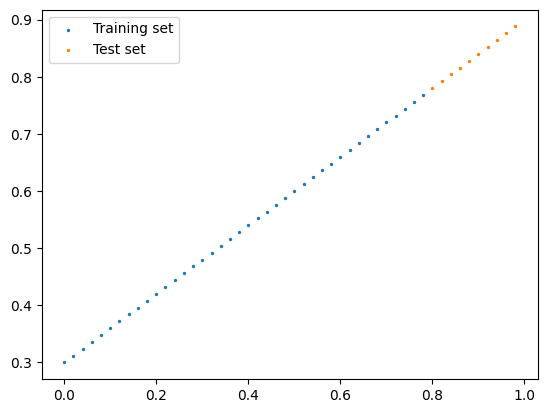

In [177]:
plt.scatter(X_train, y_train, s=2, label = 'Training set')
plt.scatter(X_test, y_test, s=2, label = 'Test set')
plt.legend()

### 6.2 PyTorch Linear Model

In [183]:
# Create a linear model by subclassing nn.Module

class LinearRegressionModelV2(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Use nn.Linear() for creating the model parameters / also called linear transform, probing layer, fullly connected layer, dense layer
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
    
# set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [180]:
X_train[:5], y_train[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3120],
         [0.3240],
         [0.3360],
         [0.3480]]))

In [185]:
# set the model to use the target device
next(model_1.parameters()).device

device(type='cpu')

In [186]:
model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [187]:
next(model_1.parameters()).device

device(type='cpu')

In [188]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

### Training

For training we need:
* Loss function
* Optimizer
* Training loop
* Testing loop

In [189]:
# setup a loss function
loss_fn = nn.L1Loss() # MAE

# setup our optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr = 0.001)

In [190]:
# Training loop
torch.manual_seed(42)

epochs = 1000
for epoch in range(epochs):
    model_1.train()

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y_train)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropagation
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        
        test_loss = loss_fn(test_pred, y_test)

    # Print out what's happening

    if epoch % 10 == 0:
        print(f'Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}')

Epoch: 0 | Loss: 0.5941779017448425 | Test loss: 0.6751000881195068
Epoch: 10 | Loss: 0.5826570987701416 | Test loss: 0.661629319190979
Epoch: 20 | Loss: 0.5711362361907959 | Test loss: 0.6481584310531616
Epoch: 30 | Loss: 0.5596153736114502 | Test loss: 0.6346877217292786
Epoch: 40 | Loss: 0.5480945706367493 | Test loss: 0.6212168335914612
Epoch: 50 | Loss: 0.5365737080574036 | Test loss: 0.6077460050582886
Epoch: 60 | Loss: 0.5250529050827026 | Test loss: 0.5942752361297607
Epoch: 70 | Loss: 0.5135320425033569 | Test loss: 0.5808044672012329
Epoch: 80 | Loss: 0.5020111799240112 | Test loss: 0.5673335790634155
Epoch: 90 | Loss: 0.49049028754234314 | Test loss: 0.5538627505302429
Epoch: 100 | Loss: 0.47896942496299744 | Test loss: 0.5403919816017151
Epoch: 110 | Loss: 0.46744856238365173 | Test loss: 0.5269211530685425
Epoch: 120 | Loss: 0.4559277594089508 | Test loss: 0.5134503245353699
Epoch: 130 | Loss: 0.4444069266319275 | Test loss: 0.49997955560684204
Epoch: 140 | Loss: 0.4328861

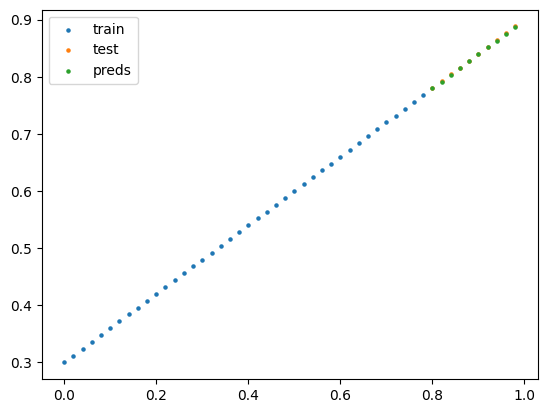

In [197]:
plt.scatter(X_train, y_train, s=5, label='train')
plt.scatter(X_test, y_test, s=5, label = 'test')
plt.scatter(X_test, test_pred, s=5, label = 'preds')
plt.legend()

In [193]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.5994]])),
             ('linear_layer.bias', tensor([0.3000]))])

In [194]:
weight, bias

(0.6, 0.3)

In [198]:
from pathlib import Path

# Create models directory
model_path = Path('models')
model_path.mkdir(parents=True, exist_ok=True)

# Create model save path
model_name = '01_pytorch_workflow_model_1.pth'
model_save_path = model_path / model_name

In [199]:
model_save_path

WindowsPath('models/01_pytorch_workflow_model_1.pth')

In [200]:
torch.save(obj=model_1.state_dict(),
           f = model_save_path)

In [202]:
loaded_model_1 = LinearRegressionModelV2()
loaded_model_1.load_state_dict(torch.load(model_save_path))

<All keys matched successfully>

In [ ]:
loaded_model_1.state_dict()     

OrderedDict([('linear_layer.weight', tensor([[0.5994]])),
             ('linear_layer.bias', tensor([0.3000]))])

In [204]:
loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [252]:
weight = 0.3
bias = 0.9
start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

In [253]:
cut = int(0.8 * len(X))
X_train, X_test, y_train, y_test = X[:cut], X[cut:], y[:cut], y[cut:]

In [255]:
class LinearRegressionModelExc(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # self.weight = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        # self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.params = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.params(x)

In [256]:
torch.manual_seed(42)
model_exc = LinearRegressionModelExc()
model_exc.state_dict()

OrderedDict([('params.weight', tensor([[0.7645]])),
             ('params.bias', tensor([0.8300]))])

In [257]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_exc.parameters(), lr = 0.001)

In [267]:
epochs = 300

for epoch in range(epochs):
    model_exc.train()

    y_pred = model_exc(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_exc.eval()

    if epoch % 20 == 0:
        with torch.inference_mode():
            preds = model_exc(X_test)

        test_loss = loss_fn(preds, y_test)
        print(f'Epoch: {epoch}, train loss: {loss}, test loss: {test_loss}')

Epoch: 0, train loss: 0.000656363379675895, test loss: 0.0008353829616680741
Epoch: 20, train loss: 0.000656363379675895, test loss: 0.0008353829616680741
Epoch: 40, train loss: 0.000656363379675895, test loss: 0.0008353829616680741
Epoch: 60, train loss: 0.000656363379675895, test loss: 0.0008353829616680741
Epoch: 80, train loss: 0.000656363379675895, test loss: 0.0008353829616680741
Epoch: 100, train loss: 0.000656363379675895, test loss: 0.0008353829616680741
Epoch: 120, train loss: 0.000656363379675895, test loss: 0.0008353829616680741
Epoch: 140, train loss: 0.000656363379675895, test loss: 0.0008353829616680741
Epoch: 160, train loss: 0.000656363379675895, test loss: 0.0008353829616680741
Epoch: 180, train loss: 0.000656363379675895, test loss: 0.0008353829616680741
Epoch: 200, train loss: 0.000656363379675895, test loss: 0.0008353829616680741
Epoch: 220, train loss: 0.000656363379675895, test loss: 0.0008353829616680741
Epoch: 240, train loss: 0.000656363379675895, test loss: 0

In [ ]:
list()

tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800, 0.1000, 0.1200, 0.1400, 0.1600,
        0.1800, 0.2000, 0.2200, 0.2400, 0.2600, 0.2800, 0.3000, 0.3200, 0.3400,
        0.3600, 0.3800, 0.4000, 0.4200, 0.4400, 0.4600, 0.4800, 0.5000, 0.5200,
        0.5400, 0.5600, 0.5800, 0.6000, 0.6200, 0.6400, 0.6600, 0.6800, 0.7000,
        0.7200, 0.7400, 0.7600, 0.7800])

In [268]:
# CTRL + SHIFT + SPACE - rozwija info o komendzie
# CTRL + SPACE - rozwija liste komend
# ALT + F12 - wyszukuje def w dokumencie